In [1]:
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device


device(type='mps')

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

len(train_ds), len(test_ds)


(60000, 10000)

In [3]:
def make_clients_noniid(dataset, n_clients=5, samples_per_client=4000, classes_per_client=3):
    # indicizza esempi per classe
    targets = np.array(dataset.targets)
    idx_by_class = {c: np.where(targets == c)[0].tolist() for c in range(10)}
    for c in idx_by_class:
        random.shuffle(idx_by_class[c])
    
    client_indices = []
    for _ in range(n_clients):
        chosen_classes = random.sample(range(10), classes_per_client)
        idxs = []
        # prendi un terzo dei campioni per ciascuna classe scelta
        per_class = samples_per_client // classes_per_client
        for c in chosen_classes:
            take = idx_by_class[c][:per_class]
            idx_by_class[c] = idx_by_class[c][per_class:]
            idxs.extend(take)
        random.shuffle(idxs)
        client_indices.append(idxs)
    return client_indices

n_clients = 5
client_idxs = make_clients_noniid(train_ds, n_clients=n_clients, samples_per_client=4000, classes_per_client=3)
[len(ix) for ix in client_idxs], sum(len(ix) for ix in client_idxs)


/var/folders/l6/jwwxj6n11nx5sd7lz1jwgfrh0000gn/T/ipykernel_25809/2011709272.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  targets = np.array(dataset.targets)


([3999, 3999, 3999, 3999, 3999], 19995)

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # 14x14
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # 7x7
            nn.Flatten(),
            nn.Linear(32*7*7, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(x)

def evaluate(model, dataset, batch_size=256):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    correct, total = 0, 0
    loss_sum = 0.0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            loss_sum += loss.item() * y.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return loss_sum/total, correct/total


In [12]:
class SimpleCNN_DLG(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), nn.ReLU(),   # 14x14
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU(),  # 7x7
            nn.Flatten(),
            nn.Linear(32*7*7, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x):
        return self.net(x)


In [5]:
def local_train(model, dataset_subset, epochs=1, lr=0.01, batch_size=64):
    model = copy.deepcopy(model).to(device)
    model.train()
    loader = DataLoader(dataset_subset, batch_size=batch_size, shuffle=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    
    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
    return model.state_dict(), len(dataset_subset)


In [6]:
def fedavg(state_dicts, weights):
    # weights: n_i (numero esempi client)
    total = sum(weights)
    avg = copy.deepcopy(state_dicts[0])
    for k in avg.keys():
        avg[k] = avg[k] * 0.0  # azzera
    
    for sd, n_i in zip(state_dicts, weights):
        for k in avg.keys():
            avg[k] += sd[k] * (n_i / total)
    return avg


In [8]:
global_model = SimpleCNN().to(device)

rounds = 10
local_epochs = 2
lr = 0.01

print("Initial test:", evaluate(global_model, test_ds))

for r in range(1, rounds+1):
    client_states = []
    client_sizes = []
    
    for i in range(n_clients):
        subset = Subset(train_ds, client_idxs[i])
        sd, n_i = local_train(global_model, subset, epochs=local_epochs, lr=lr)
        client_states.append(sd)
        client_sizes.append(n_i)
    
    new_global = fedavg(client_states, client_sizes)
    global_model.load_state_dict(new_global)
    
    test_loss, test_acc = evaluate(global_model, test_ds)
    print(f"Round {r:02d} | test loss={test_loss:.4f} | test acc={test_acc:.4f}")


Initial test: (2.3082252727508545, 0.123)
Round 01 | test loss=1.9818 | test acc=0.3358
Round 02 | test loss=1.8181 | test acc=0.5549
Round 03 | test loss=1.8927 | test acc=0.5621
Round 04 | test loss=1.6225 | test acc=0.7138
Round 05 | test loss=2.1608 | test acc=0.5806
Round 06 | test loss=1.6491 | test acc=0.7242
Round 07 | test loss=1.9487 | test acc=0.6857
Round 08 | test loss=1.6957 | test acc=0.7551
Round 09 | test loss=1.8429 | test acc=0.7573
Round 10 | test loss=1.7705 | test acc=0.7702


In [13]:
global_model_attack = SimpleCNN_DLG().to(device)
print("Initial test (attack model):", evaluate(global_model_attack, test_ds))


Initial test (attack model): (2.299426496887207, 0.1121)


In [14]:
rounds_attack = 3
local_epochs_attack = 1
lr_attack = 0.02

for r in range(1, rounds_attack+1):
    client_states, client_sizes = [], []
    for i in range(n_clients):
        subset = Subset(train_ds, client_idxs[i])
        sd, n_i = local_train(global_model_attack, subset, epochs=local_epochs_attack, lr=lr_attack)
        client_states.append(sd)
        client_sizes.append(n_i)

    new_global = fedavg(client_states, client_sizes)
    global_model_attack.load_state_dict(new_global)

    tl, ta = evaluate(global_model_attack, test_ds)
    print(f"[attack model] Round {r:02d} | test loss={tl:.4f} | test acc={ta:.4f}")


[attack model] Round 01 | test loss=1.9764 | test acc=0.3309
[attack model] Round 02 | test loss=1.7930 | test acc=0.5543
[attack model] Round 03 | test loss=1.7486 | test acc=0.5989


In [15]:
def get_gradients_on_batch(model, x, y):
    model = copy.deepcopy(model).to(device)
    model.train()
    criterion = nn.CrossEntropyLoss()
    model.zero_grad()
    logits = model(x)
    loss = criterion(logits, y)
    loss.backward()
    grads = [p.grad.detach().clone() for p in model.parameters() if p.requires_grad]
    return grads


In [16]:
def dlg_reconstruct(model, target_grads, y_true, iters=300, lr=0.1, print_every=50):
    model = copy.deepcopy(model).to(device)
    model.train()

    # input finto iniziale
    x_dummy = torch.randn((1, 1, 28, 28), device=device, requires_grad=True)

    optimizer = optim.LBFGS([x_dummy], lr=lr, max_iter=1)  # un passo per iterazione
    criterion = nn.CrossEntropyLoss()

    # per confrontare, fissiamo label vera (attaccante può conoscerla o indovinarla; qui assumiamo che la conosca)
    y = y_true.to(device)

    for t in range(1, iters + 1):
        def closure():
            optimizer.zero_grad()
            model.zero_grad()

            logits = model(x_dummy)
            loss = criterion(logits, y)
            grads_dummy = torch.autograd.grad(loss, [p for p in model.parameters() if p.requires_grad], create_graph=True)

            # matching tra gradienti veri e dummy
            grad_loss = 0.0
            for gd, gt in zip(grads_dummy, target_grads):
                grad_loss = grad_loss + ((gd - gt)**2).sum()

            grad_loss.backward()
            return grad_loss

        loss_val = optimizer.step(closure)

        if t % print_every == 0:
            print(f"iter {t:04d} | grad match loss: {loss_val.item():.2f}")

    return x_dummy.detach().cpu()


iter 0050 | grad match loss: 0.04
iter 0100 | grad match loss: 0.00
iter 0150 | grad match loss: 0.00
iter 0200 | grad match loss: 0.00
iter 0250 | grad match loss: 0.00
iter 0300 | grad match loss: 0.00
iter 0350 | grad match loss: 0.00
iter 0400 | grad match loss: 0.00


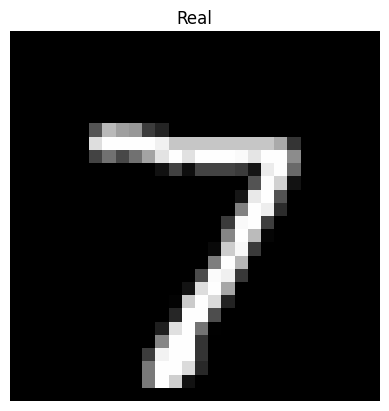

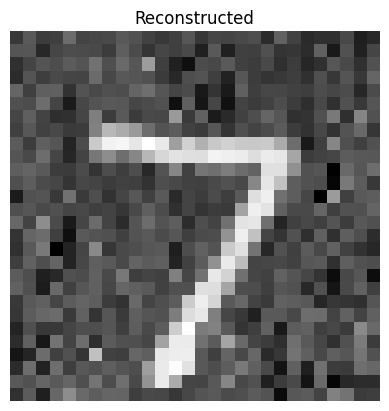

In [17]:
import matplotlib.pyplot as plt

# prendi un esempio reale
idx = 0
x_real, y_real = test_ds[idx]
x_real = x_real.unsqueeze(0).to(device)  # batch=1
y_real = torch.tensor([y_real])

# gradienti "osservati" dall'attaccante
target_grads = get_gradients_on_batch(global_model_attack, x_real, y_real.to(device))

# ricostruzione
x_rec = dlg_reconstruct(global_model_attack, target_grads, y_real, iters=400, lr=0.1, print_every=50)

# plot
plt.figure()
plt.title("Real")
plt.imshow(test_ds[idx][0].squeeze(), cmap="gray")
plt.axis("off")
plt.show()

plt.figure()
plt.title("Reconstructed")
plt.imshow(x_rec.squeeze(), cmap="gray")
plt.axis("off")
plt.show()


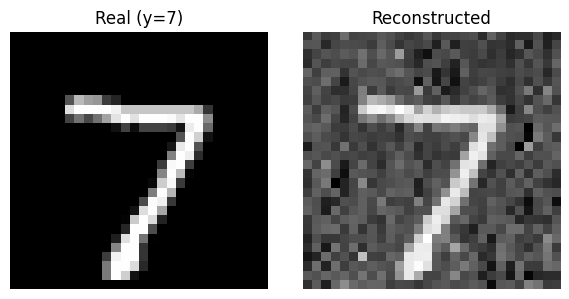

In [18]:
import matplotlib.pyplot as plt

def plot_and_save(real_img, rec_img, y, fname="dlg_mnist_example.png"):
    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.title(f"Real (y={int(y)})")
    plt.imshow(real_img.squeeze(), cmap="gray")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Reconstructed")
    plt.imshow(rec_img.squeeze(), cmap="gray")
    plt.axis("off")

    plt.tight_layout()
    plt.savefig(fname, dpi=200)
    plt.show()

# usa questa, con gli oggetti che hai già
plot_and_save(test_ds[idx][0], x_rec, y_real.item(), fname="dlg_mnist_example.png")


In [19]:
def mse(a, b):
    a = a.float()
    b = b.float()
    return torch.mean((a - b)**2).item()

def attack_many(model, dataset, indices, iters=400, lr=0.1):
    results = []
    for j, idx in enumerate(indices, 1):
        x_real, y = dataset[idx]
        x_real_b = x_real.unsqueeze(0).to(device)
        y_b = torch.tensor([y]).to(device)

        target_grads = get_gradients_on_batch(model, x_real_b, y_b)
        x_rec = dlg_reconstruct(model, target_grads, torch.tensor([y]), iters=iters, lr=lr, print_every=999999)

        m = mse(torch.tensor(x_real.squeeze()), torch.tensor(x_rec.squeeze()))
        
        # prediction on reconstructed
        model.eval()
        with torch.no_grad():
            pred = model(torch.tensor(x_rec).unsqueeze(0).to(device) if x_rec.ndim==2 else torch.tensor(x_rec).to(device))
            pred_label = int(pred.argmax(dim=1).item())

        results.append({"idx": idx, "y": int(y), "pred_on_rec": pred_label, "mse": m})
        print(f"{j}/{len(indices)} idx={idx} y={y} pred_rec={pred_label} mse={m:.4f}")

    return results

# prova su 5 esempi
indices = [0, 1, 2, 3, 4]
res = attack_many(global_model_attack, test_ds, indices, iters=400, lr=0.1)
res


/var/folders/l6/jwwxj6n11nx5sd7lz1jwgfrh0000gn/T/ipykernel_25809/3340236211.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  m = mse(torch.tensor(x_real.squeeze()), torch.tensor(x_rec.squeeze()))
/var/folders/l6/jwwxj6n11nx5sd7lz1jwgfrh0000gn/T/ipykernel_25809/3340236211.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pred = model(torch.tensor(x_rec).unsqueeze(0).to(device) if x_rec.ndim==2 else torch.tensor(x_rec).to(device))


1/5 idx=0 y=7 pred_rec=7 mse=0.2371
2/5 idx=1 y=2 pred_rec=8 mse=0.1425
3/5 idx=2 y=1 pred_rec=1 mse=0.1101
4/5 idx=3 y=0 pred_rec=0 mse=0.1112
5/5 idx=4 y=4 pred_rec=4 mse=2032.7933


[{'idx': 0, 'y': 7, 'pred_on_rec': 7, 'mse': 0.2370777130126953},
 {'idx': 1, 'y': 2, 'pred_on_rec': 8, 'mse': 0.1424991488456726},
 {'idx': 2, 'y': 1, 'pred_on_rec': 1, 'mse': 0.11011438071727753},
 {'idx': 3, 'y': 0, 'pred_on_rec': 0, 'mse': 0.1112055703997612},
 {'idx': 4, 'y': 4, 'pred_on_rec': 4, 'mse': 2032.7933349609375}]

## Implementing in AIJack

In [29]:
# =========================
# AIJack FedAvg (MNIST) with your non-IID split
# Mac-safe version (FORCES CPU to avoid MPS/NNPACK mismatch)
# Paste this into a fresh notebook, run top-to-bottom.
# =========================

# --- Cell 1: imports + seed + FORCE CPU
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from aijack.collaborative.fedavg import FedAVGClient, FedAVGServer, FedAVGAPI

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# IMPORTANT: force CPU (stable on Mac)
device = torch.device("cpu")
device


# --- Cell 2: dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)


# --- Cell 3: your non-IID split
def make_clients_noniid(dataset, n_clients=5, samples_per_client=4000, classes_per_client=3):
    targets = dataset.targets.detach().cpu().numpy()
    idx_by_class = {c: np.where(targets == c)[0].tolist() for c in range(10)}
    for c in idx_by_class:
        random.shuffle(idx_by_class[c])

    client_indices = []
    for _ in range(n_clients):
        chosen_classes = random.sample(range(10), classes_per_client)
        idxs = []
        per_class = samples_per_client // classes_per_client
        for c in chosen_classes:
            take = idx_by_class[c][:per_class]
            idx_by_class[c] = idx_by_class[c][per_class:]
            idxs.extend(take)
        random.shuffle(idxs)
        client_indices.append(idxs)
    return client_indices

n_clients = 5
client_idxs = make_clients_noniid(train_ds, n_clients=n_clients, samples_per_client=4000, classes_per_client=3)
print([len(ix) for ix in client_idxs], "total:", sum(len(ix) for ix in client_idxs))


# --- Cell 4: dataloaders per client
training_batch_size = 64
local_dataloaders = [
    DataLoader(Subset(train_ds, client_idxs[i]), batch_size=training_batch_size, shuffle=True)
    for i in range(n_clients)
]


# --- Cell 5: model (no MaxPool; returns log-probs for NLLLoss)
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, stride=2, padding=1)   # 14x14
        self.conv2 = nn.Conv2d(16, 32, 3, stride=2, padding=1)  # 7x7
        self.fc1 = nn.Linear(32*7*7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

criterion = F.nll_loss


# --- Cell 6: evaluation callback (FORCES CPU tensors and model)
def evaluate_global_model(dataloader):
    def _evaluate(api):
        api.server.to("cpu")
        api.server.eval()

        test_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for x, y in dataloader:
                x = x.to("cpu")
                y = y.to("cpu")

                out = api.server(x)
                test_loss += F.nll_loss(out, y, reduction="sum").item()
                pred = out.argmax(dim=1)
                correct += (pred == y).sum().item()
                total += y.size(0)

        test_loss /= total
        acc = 100.0 * correct / total
        print(f"[AIJack] Test loss={test_loss:.4f} | Test acc={acc:.2f}%")

    return _evaluate


# --- Cell 7: build clients/server/api + run
num_rounds = 10
lr = 0.01

# IMPORTANT: instantiate models on CPU (no .to(device) needed since device=cpu)
clients = [FedAVGClient(Net(), user_id=i) for i in range(n_clients)]
local_optimizers = [optim.SGD(clients[i].parameters(), lr=lr, momentum=0.9) for i in range(n_clients)]

server = FedAVGServer(clients, Net())

api = FedAVGAPI(
    server=server,
    clients=clients,
    criterion=criterion,
    local_optimizers=local_optimizers,
    local_dataloaders=local_dataloaders,
    num_communication=num_rounds,
    custom_action=evaluate_global_model(test_loader),
    device=torch.device("cpu"),   # keep explicit
)

# extra safety (prevents stale device state)
api.device = torch.device("cpu")

api.server.distribute()
api.run()


[3999, 3999, 3999, 3999, 3999] total: 19995
[AIJack] Test loss=3.6629 | Test acc=22.74%
[AIJack] Test loss=1.7115 | Test acc=59.12%
[AIJack] Test loss=2.7487 | Test acc=39.38%
[AIJack] Test loss=2.0605 | Test acc=58.20%
[AIJack] Test loss=2.6665 | Test acc=40.83%
[AIJack] Test loss=1.6458 | Test acc=65.65%
[AIJack] Test loss=1.9824 | Test acc=59.05%
[AIJack] Test loss=1.6439 | Test acc=72.93%
[AIJack] Test loss=1.8399 | Test acc=71.57%
[AIJack] Test loss=1.7823 | Test acc=73.66%


In [30]:
import copy
import torch
import torch.optim as optim
import torch.nn.functional as F

def dlg_reconstruct_nll(model, target_grads, y_true, iters=400, lr=0.1, print_every=50):
    model = copy.deepcopy(model).to("cpu")
    model.train()

    # dummy input (MNIST shape)
    x_dummy = torch.randn((1, 1, 28, 28), requires_grad=True)

    optimizer = optim.LBFGS([x_dummy], lr=lr, max_iter=1)

    # y_true must be a tensor shape [1]
    if not torch.is_tensor(y_true):
        y_true = torch.tensor([y_true], dtype=torch.long)
    if y_true.ndim == 0:
        y_true = y_true.unsqueeze(0)
    y_true = y_true.to("cpu")

    params = [p for p in model.parameters() if p.requires_grad]

    for t in range(1, iters + 1):
        def closure():
            optimizer.zero_grad()
            model.zero_grad()

            out = model(x_dummy)              # log-probs
            loss = F.nll_loss(out, y_true)    # NLLLoss
            grads_dummy = torch.autograd.grad(loss, params, create_graph=True)

            grad_loss = 0.0
            for gd, gt in zip(grads_dummy, target_grads):
                grad_loss = grad_loss + ((gd - gt)**2).sum()

            grad_loss.backward()
            return grad_loss

        loss_val = optimizer.step(closure)

        if t % print_every == 0:
            print(f"iter {t:04d} | grad match loss: {loss_val.item():.2f}")

    return x_dummy.detach()


In [31]:
def get_one_batch_from_client(local_dataloaders, client_id=0):
    x, y = next(iter(local_dataloaders[client_id]))
    return x, y

def get_gradients_on_batch_model_nll(model, x, y):
    model = copy.deepcopy(model).to("cpu")
    model.train()
    model.zero_grad()
    out = model(x)
    loss = F.nll_loss(out, y)
    loss.backward()
    grads = [p.grad.detach().clone() for p in model.parameters() if p.requires_grad]
    return grads


iter 0050 | grad match loss: 3.04
iter 0100 | grad match loss: 0.91
iter 0150 | grad match loss: 0.42
iter 0200 | grad match loss: 0.34
iter 0250 | grad match loss: 0.05
iter 0300 | grad match loss: 0.28
iter 0350 | grad match loss: 0.03
iter 0400 | grad match loss: 0.05


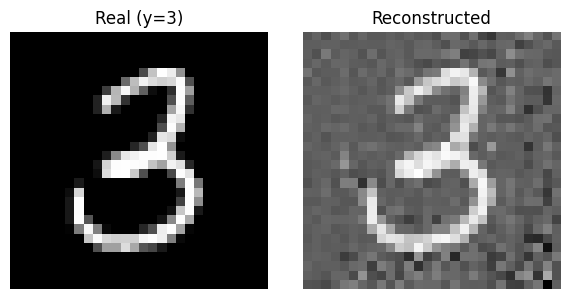

In [32]:
import matplotlib.pyplot as plt

victim_id = 0

# batch dal client (CPU)
x_batch, y_batch = get_one_batch_from_client(local_dataloaders, client_id=victim_id)
x_real = x_batch[:1].to("cpu")
y_real = y_batch[:1].to("cpu")

# modello del client AIJack dopo training
victim_model = api.clients[victim_id].model  # already trained inside AIJack

# gradienti "osservati"
target_grads = get_gradients_on_batch_model_nll(victim_model, x_real, y_real)

# ricostruzione
x_rec = dlg_reconstruct_nll(victim_model, target_grads, y_real, iters=400, lr=0.1, print_every=50)

# plot
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.title(f"Real (y={int(y_real.item())})")
plt.imshow(x_real.squeeze(), cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Reconstructed")
plt.imshow(x_rec.squeeze(), cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()


In [33]:
def mse(a, b):
    return torch.mean((a.float() - b.float())**2).item()

def attack_n_examples(api, local_dataloaders, victim_id=0, n=10, iters=400, lr=0.1):
    victim_model = api.clients[victim_id].model
    loader = iter(local_dataloaders[victim_id])

    rows = []
    for i in range(n):
        x_batch, y_batch = next(loader)
        x_real = x_batch[:1].to("cpu")
        y_real = y_batch[:1].to("cpu")

        target_grads = get_gradients_on_batch_model_nll(victim_model, x_real, y_real)
        x_rec = dlg_reconstruct_nll(victim_model, target_grads, y_real, iters=iters, lr=lr, print_every=999999)

        rows.append({
            "i": i,
            "y": int(y_real.item()),
            "mse": mse(x_real, x_rec),
        })
        print(f"{i+1}/{n} done | y={rows[-1]['y']} | mse={rows[-1]['mse']:.4f}")

    return rows

rows = attack_n_examples(api, local_dataloaders, victim_id=0, n=5, iters=400, lr=0.1)
rows


1/5 done | y=4 | mse=494982.1250
2/5 done | y=4 | mse=4704.8232
3/5 done | y=5 | mse=21219.6680
4/5 done | y=3 | mse=0.0543
5/5 done | y=4 | mse=9455.3594


[{'i': 0, 'y': 4, 'mse': 494982.125},
 {'i': 1, 'y': 4, 'mse': 4704.8232421875},
 {'i': 2, 'y': 5, 'mse': 21219.66796875},
 {'i': 3, 'y': 3, 'mse': 0.054250482469797134},
 {'i': 4, 'y': 4, 'mse': 9455.359375}]